# Trafic routier à Paris : rue Lecourbe, avenue Foch et avenue Daumesnil

**Question.** Comment le trafic évolue-t-il sur trois axes parisiens, et lequel supporte le débit horaire le plus élevé ?

**Données.** Comptages routiers permanents de la Ville de Paris : des boucles dans la chaussée mesurent le trafic heure par heure, tronçon par tronçon. L'étude porte sur la rue Lecourbe, l'avenue Foch et l'avenue Daumesnil, du 1er mars au 31 août 2026.

Source : https://opendata.paris.fr/explore/dataset/comptages-routiers-permanents/

**Plan du notebook.**

1. Jalon M1 : chargement et exploration
2. Jalon M2 : types et nettoyage
3. Jalon M3 : transformation et statistiques
4. Jalon 4 : analyse et présentation

# Jalon M1 : Chargement et exploration

In [1]:
from pathlib import Path
import os

import requests
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ROUTES = ["Lecourbe", "Av_Foch", "Av_Daumesnil"]
DATE_DEBUT = "2026-03-01"
DATE_FIN = "2026-09-01"  # exclue

In [3]:
URL = ("https://opendata.paris.fr/api/explore/v2.1/catalog/datasets/"
       "comptages-routiers-permanents/exports/csv")
COLONNES = ("iu_ac,libelle,t_1h,q,k,etat_trafic,iu_nd_amont,libelle_nd_amont,"
            "iu_nd_aval,libelle_nd_aval,etat_barre")
SORTIE = Path(os.getcwd()) / "data" / "comptages_trafic.csv"

CHEMIN = SORTIE


In [4]:
def main():
    if len(ROUTES) != 3:
        raise SystemExit("Renseignez vos 3 axes dans ROUTES avant de lancer le téléchargement.")
    axes = ",".join(f"'{r}'" for r in ROUTES)
    params = {
        "select": COLONNES,
        "where": f"libelle in ({axes}) and t_1h >= date'{DATE_DEBUT}' and t_1h < date'{DATE_FIN}'",
    }
    SORTIE.parent.mkdir(parents=True, exist_ok=True)
    print("Téléchargement en cours (1 à 3 minutes)...")
    with requests.get(URL, params=params, stream=True, timeout=600) as r:
        r.raise_for_status()
        with open(SORTIE, "wb") as f:
            for chunk in r.iter_content(1 << 20):
                f.write(chunk)
    taille = SORTIE.stat().st_size / 1e6
    if taille < 0.01:
        raise SystemExit("Fichier vide : vérifiez l'orthographe de vos axes dans ROUTES.")
    print(f"{SORTIE} : {taille:.1f} Mo")

if not SORTIE.exists():  # évite de retélécharger à chaque exécution
    main()

In [5]:
TYPES = {
    "iu_ac": "string", "iu_nd_amont": "string", "iu_nd_aval": "string",
    "libelle": "category", "etat_trafic": "category", "etat_barre": "category",
}

morceaux = []
for i, chunk in enumerate(pd.read_csv(CHEMIN, sep=";", encoding="utf-8-sig",
                                      dtype=TYPES, chunksize=50_000)):
    morceaux.append(chunk)
print(f"{i + 1} chunks lus")

df = pd.concat(morceaux, ignore_index=True)


5 chunks lus


In [6]:
df.shape

(200744, 11)

In [7]:
df.head()

,iu_ac,libelle,t_1h,q,k,etat_trafic,iu_nd_amont,libelle_nd_amont,iu_nd_aval,libelle_nd_aval,etat_barre
0,5582,Lecourbe,2026-08-31T23:00:00+00:00,198.0,NaN,Inconnu,2932,Lecourbe-Volontaires,2933,Lecourbe-Cambronne,Ouvert
1,5584,Lecourbe,2026-08-31T23:00:00+00:00,198.0,0.82722,Fluide,2934,Lecourbe-Roussin,2935,Lecourbe-Seche-Peclet,Ouvert
2,4383,Av_Foch,2026-08-31T23:00:00+00:00,145.0,0.40667,Fluide,2351,Foch-Pergolese,2347,Av_Foch-Av_Malakoff,Ouvert
3,4384,Av_Foch,2026-08-31T23:00:00+00:00,464.0,3.03556,Fluide,2351,Foch-Pergolese,2352,Pte_Dauphine-Foch,Ouvert
4,4385,Av_Foch,2026-08-31T23:00:00+00:00,145.0,1.89667,Fluide,2352,Pte_Dauphine-Foch,2351,Foch-Pergolese,Ouvert


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200744 entries, 0 to 200743
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   iu_ac             200744 non-null  string  
 1   libelle           200744 non-null  category
 2   t_1h              200744 non-null  str     
 3   q                 129679 non-null  float64 
 4   k                 137621 non-null  float64 
 5   etat_trafic       200744 non-null  str     
 6   iu_nd_amont       200744 non-null  string  
 7   libelle_nd_amont  200744 non-null  str     
 8   iu_nd_aval        200744 non-null  string  
 9   libelle_nd_aval   200744 non-null  str     
 10  etat_barre        200744 non-null  str     
dtypes: category(1), float64(2), str(5), string(3)
memory usage: 15.5 MB


In [9]:
df.dtypes

iu_ac                 string
libelle             category
t_1h                     str
q                    float64
k                    float64
etat_trafic              str
iu_nd_amont           string
libelle_nd_amont         str
iu_nd_aval            string
libelle_nd_aval          str
etat_barre               str
dtype: object

In [10]:
df.isnull().sum()

iu_ac                   0
libelle                 0
t_1h                    0
q                   71065
k                   63123
etat_trafic             0
iu_nd_amont             0
libelle_nd_amont        0
iu_nd_aval              0
libelle_nd_aval         0
etat_barre              0
dtype: int64

In [11]:
print(f"Il y a {len(df.dropna())} lignes sans valeurs manquantes sur {len(df)} lignes au total. Soit {len(df.dropna()) / len(df) * 100:.1f}% de lignes complètes.")

Il y a 100396 lignes sans valeurs manquantes sur 200744 lignes au total. Soit 50.0% de lignes complètes.


In [12]:
df[["q", "k"]].describe().round(1)

,q,k
count,129679.0,137621.0
mean,308.2,6.6
std,258.1,10.1
min,0.0,0.0
25%,125.0,1.4
50%,226.0,3.2
75%,422.0,7.1
max,5518.0,97.1


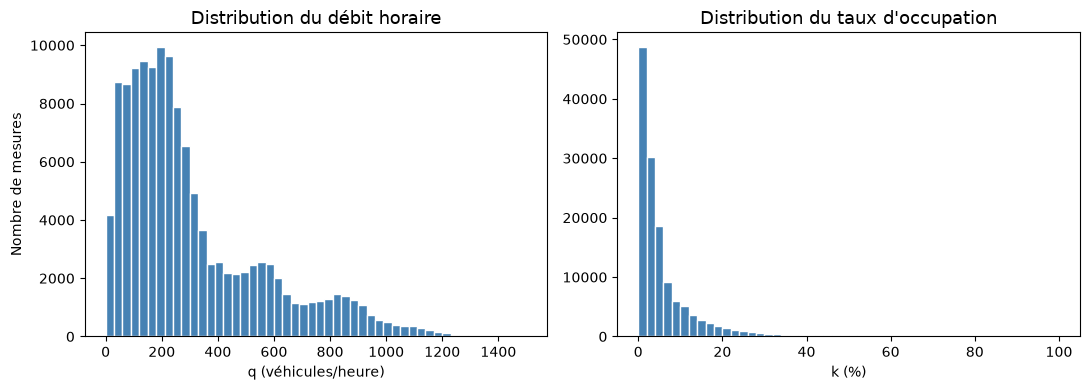

16 valeurs de q dépassent 1 500 véhicules/heure et sortent du graphique
44.7 % des valeurs de k renseignées sont sous 5 % ; 64.4 % des valeurs de q sont sous 300


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df["q"].dropna(), bins=50, range=(0, 1500), color="steelblue", edgecolor="white")
axes[0].set_title("Distribution du débit horaire", fontsize=13)
axes[0].set_xlabel("q (véhicules/heure)")
axes[0].set_ylabel("Nombre de mesures")

axes[1].hist(df["k"].dropna(), bins=50, range=(0, 100), color="steelblue", edgecolor="white")
axes[1].set_title("Distribution du taux d'occupation", fontsize=13)
axes[1].set_xlabel("k (%)")

plt.tight_layout()
plt.show()

print(f"{(df['q'] > 1500).sum()} valeurs de q dépassent 1 500 véhicules/heure et sortent du graphique")
print(f"{(df['k'] < 5).mean() * 100:.1f} % des valeurs de k renseignées sont sous 5 % ; {(df['q'] < 300).sum() / df['q'].notna().sum() * 100:.1f} % des valeurs de q sont sous 300")

**Ce que montrent le tableau et les graphiques.**

- Le débit `q` est très étalé vers la droite : la médiane est de 226 véhicules/heure pour une moyenne de 308, et 64,4 % des mesures sont sous 300. L'histogramme montre trois bosses, autour de 200, 550 et 850 véhicules/heure : les données mélangent des axes de niveaux de trafic très différents (voir le graphique par axe plus bas).
- Le maximum de `q` (5 518) vaut 24 fois la médiane, et 16 valeurs dépassent 1 500 : ces valeurs extrêmes sont examinées dans la partie sur les valeurs aberrantes.
- Le taux d'occupation `k` est concentré près de zéro : médiane de 3,2 %, et 44,7 % des valeurs sous 5 %. Il monte jusqu'à 97,1 %, mais ces valeurs élevées sont rares.

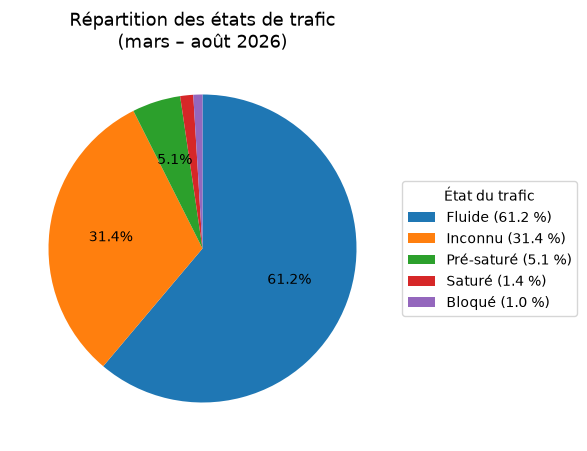

In [14]:
counts = df["etat_trafic"].value_counts()
pct = counts / counts.sum() * 100

ax = counts.plot.pie(
    figsize=(7, 5),
    autopct=lambda p: f"{p:.1f}%" if p >= 5 else "", 
    labels=None,
    ylabel="",
    startangle=90,
    counterclock=False,
)
ax.set_title("Répartition des états de trafic\n(mars – août 2026)", fontsize=13)
ax.legend(
    [f"{etat} ({p:.1f} %)" for etat, p in pct.items()],
    title="État du trafic",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
)
plt.show()


**Ce que montre le graphique.** Sur les données brutes, 61,2 % des mesures horaires sont classées « Fluide », contre 5,1 % « Pré-saturé », 1,4 % « Saturé » et 1,0 % « Bloqué ». Mais 31,4 % des lignes sont « Inconnu » : près d'une mesure sur trois n'a pas d'état de trafic exploitable. Cette modalité est examinée dans la partie nettoyage.

libelle
Av_Foch         620.684280
Lecourbe        396.254813
Av_Daumesnil    170.218149
Name: q, dtype: float64


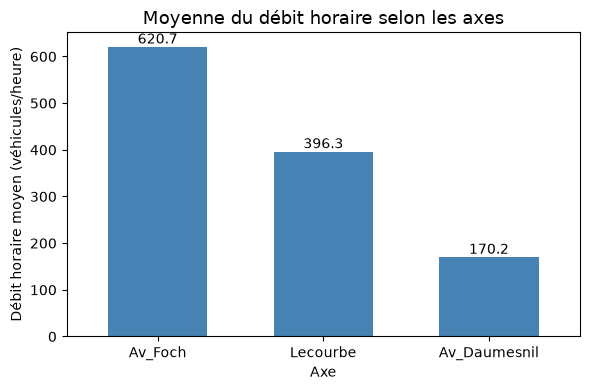

In [15]:
VAR_CAT = "libelle"   # la variable à 3 modalités
VAR_NUM = "q"   # la variable quantitative

moyennes = (
    df.groupby(VAR_CAT, observed=True)[VAR_NUM]
    .mean()
    .sort_values(ascending=False)
)
print(moyennes)

ax = moyennes.plot.bar(figsize=(6, 4), color="steelblue", width=0.6)

ax.set_title(f"Moyenne du débit horaire selon les axes", fontsize=13)
ax.set_xlabel("Axe")
ax.set_ylabel("Débit horaire moyen (véhicules/heure)")
ax.bar_label(ax.containers[0], fmt="%.1f")   # affiche la valeur au-dessus de chaque barre
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Ce que montre le graphique.** L'avenue Foch a le débit horaire moyen le plus élevé (621 véhicules/heure), devant la rue Lecourbe (396) et l'avenue Daumesnil (170). Ces moyennes sont calculées sur les seules lignes où `q` est renseigné, et tous les tronçons d'un axe y pèsent autant : elles donnent un ordre de grandeur par axe, pas le trafic d'un tronçon précis.

# Jalon M2 : Types et nettoyage

### 1. Dates et fuseau horaire

`t_1h` est lue comme du texte. Elle est convertie en date, puis passée de l'UTC à l'heure de Paris : sans cela, toutes les heures seraient décalées de 1 h (hiver) ou 2 h (été), et les heures de pointe seraient mal placées.

In [16]:
df["t_1h"] = pd.to_datetime(df["t_1h"], utc=True)
print(df["t_1h"].dtype)
print(df["t_1h"].min(), "→", df["t_1h"].max())

datetime64[us, UTC]
2026-03-01 00:00:00+00:00 → 2026-08-31 23:00:00+00:00


In [17]:
df["Date_GW"] = df["t_1h"].dt.tz_convert("Europe/Paris")
print(df["Date_GW"].min(), "→", df["Date_GW"].max())

2026-03-01 01:00:00+01:00 → 2026-09-01 01:00:00+02:00


In [18]:
hors_periode = df["Date_GW"] >= pd.Timestamp("2026-09-01", tz="Europe/Paris")
print(f"{hors_periode.sum()} lignes tombent le 1er septembre en heure de Paris")
df = df[~hors_periode].copy()

92 lignes tombent le 1er septembre en heure de Paris


**Choix.** Les dates brutes vont du 1er mars 00:00 au 31 août 23:00 en UTC, soit du 1er mars 01:00 au 1er septembre 01:00 à Paris. Les 92 lignes qui tombent le 1er septembre (2 heures × 46 tronçons) sont supprimées : elles sortent de la période étudiée et formeraient une journée de 2 heures. Il manque en contrepartie l'heure 00:00 du 1er mars.

In [19]:
df["Date"] = df["Date_GW"].dt.date

In [20]:
df["Heure"] = df["Date_GW"].dt.strftime("%H:%M")

In [21]:
noms_mois = {1: "janvier", 2: "février", 3: "mars", 4: "avril", 5: "mai", 6: "juin",
             7: "juillet", 8: "août", 9: "septembre", 10: "octobre", 11: "novembre", 12: "décembre"}

df["Mois"] = df["Date_GW"].dt.month.map(noms_mois)

In [22]:
df["Mois"].value_counts()

Mois
août       34224
juillet    34224
mai        34224
juin       33120
mars       33028
avril      31832
Name: count, dtype: int64

### 2. Types

`etat_trafic` et `etat_barre` étaient déclarées en `category` à la lecture, mais elles sont revenues en texte après l'assemblage des chunks (voir `df.dtypes` plus haut). Elles n'ont que 5 et 3 modalités : elles sont reconverties en `category`. `iu_ac` reste une chaîne, c'est un identifiant et non une quantité.

In [23]:
for col in ["etat_trafic", "etat_barre"]:
    df[col] = df[col].astype("category")
df.dtypes

iu_ac                                     string
libelle                                 category
t_1h                         datetime64[us, UTC]
q                                        float64
k                                        float64
etat_trafic                             category
iu_nd_amont                               string
libelle_nd_amont                             str
iu_nd_aval                                string
libelle_nd_aval                              str
etat_barre                              category
Date_GW             datetime64[us, Europe/Paris]
Date                                      object
Heure                                        str
Mois                                         str
dtype: object

### 3. Doublons

In [24]:
print("Lignes entièrement dupliquées :", df.duplicated().sum())
print("Doublons tronçon + heure :", df.duplicated(subset=["iu_ac", "t_1h"]).sum())

Lignes entièrement dupliquées : 0
Doublons tronçon + heure : 0


In [25]:
heures_attendues = pd.date_range(df["t_1h"].min(), df["t_1h"].max(), freq="h")
print(f"{df['t_1h'].nunique()} heures présentes sur {len(heures_attendues)} attendues")
print("Lignes par tronçon :", df.groupby("iu_ac").size().unique())

4362 heures présentes sur 4414 attendues
Lignes par tronçon : [4362]


**Constat.** Aucune ligne dupliquée, et aucun tronçon n'a deux mesures pour la même heure : il n'y a rien à supprimer. Chaque tronçon a exactement 4 362 lignes, mais la période en compte 4 414 : 52 heures sont absentes pour tous les tronçons à la fois. Ces heures n'existent pas dans la source et ne sont pas recréées.

### 4. Colonnes inutiles

In [26]:
print(df.groupby("iu_ac")[["iu_nd_amont", "iu_nd_aval"]].nunique().max())

noeuds = pd.concat([
    df[["iu_nd_amont", "libelle_nd_amont"]].set_axis(["code", "nom"], axis=1),
    df[["iu_nd_aval", "libelle_nd_aval"]].set_axis(["code", "nom"], axis=1),
]).drop_duplicates()
print(f"{len(noeuds)} couples code/nom, {noeuds['code'].nunique()} codes, {noeuds['nom'].nunique()} noms")

iu_nd_amont    1
iu_nd_aval     1
dtype: int64


33 couples code/nom, 33 codes, 33 noms


In [27]:
df = df.drop(columns=["iu_nd_amont", "iu_nd_aval"])

**Choix.** Chaque tronçon a un seul carrefour amont et un seul carrefour aval, et les 33 codes de carrefour correspondent à 33 noms exactement. Les codes `iu_nd_amont` et `iu_nd_aval` répètent donc l'information des libellés : ils sont supprimés, et les noms sont gardés car ils permettent de situer un tronçon.

### 5. Valeurs manquantes

Les valeurs manquantes sont d'abord croisées avec l'état du tronçon, puis mesurées tronçon par tronçon.

In [28]:
manquant = df["q"].isna() | df["k"].isna()
print(pd.crosstab(df["etat_barre"], manquant, colnames=["q ou k manquant"]))
print()
print(pd.crosstab(df["etat_trafic"], df["k"].isna(), colnames=["k manquant"]))

q ou k manquant   False  True 
etat_barre                    
Barré               331    504
Invalide              0  33593
Ouvert           100011  66213



k manquant    False  True 
etat_trafic               
Bloqué         1921      0
Fluide       122685      0
Inconnu           0  63101
Pré-saturé    10205      0
Saturé         2740      0


In [29]:
df.groupby("etat_barre", observed=True)["q"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
etat_barre,,,,,,,,
Barré,367.0,153.6,340.1,0.0,2.0,24.0,127.0,2179.0
Invalide,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ouvert,129248.0,308.7,257.8,0.0,125.0,226.0,423.0,5518.0


In [30]:
taux_na = (
    df.assign(q_na=df["q"].isna(), k_na=df["k"].isna())
    .groupby(["libelle", "iu_ac"], observed=True)[["q_na", "k_na"]]
    .mean()
    .mul(100)
    .round(1)
)
taux_na

q_na   k_na
libelle      iu_ac              
Av_Daumesnil 4795    86.0    8.2
             4797    13.1    8.2
             4798    13.1   85.5
             4800    13.1    8.2
             4802    86.0    8.2
             4821    57.8   58.0
             4836     1.3    1.3
             4837     1.3    3.5
             4838     1.3    1.3
             4840     1.3    7.2
             4841     1.3    3.5
             4842     0.8    0.9
             4843     8.6    0.8
             4845     0.8    0.8
             4846   100.0    4.0
             5041     0.8    7.7
             5042   100.0  100.0
             5713    86.0   86.0
             5797     8.6   11.8
             5798     0.8   11.6
             5800     0.8   11.6
             5801     8.6   11.8
             905     14.8  100.0
             906     13.1   25.8
Av_Foch      4381     1.4    1.4
             4383     4.9    1.4
             4384     1.4    4.9
             4385     4.9    5.3
             4386   100.0  100.0
             4387   100.0  100.0
             4388    39.8    2.5
             4389    39.8  100.0
             4430    39.8   40.1
             4432   100.0    3.0
             4433    39.8    1.4
             4435   100.0    1.4
Lecourbe     1117   100.0    2.5
             1119   100.0    2.5
             1120   100.0    2.5
             5581     6.2  100.0
             5582     6.2  100.0
             5583     6.2  100.0
             5584     6.2    6.3
             5585     6.2    6.3
             5586     6.2  100.0
             5587   100.0  100.0

**Constats.**

- Les 33 593 lignes `Invalide` ont toutes `q` ou `k` manquant : le capteur signale lui-même que la mesure ne vaut rien.
- Les 835 lignes `Barré` correspondent à une voie fermée : le débit médian y est de 24 véhicules/heure contre 226 quand le tronçon est ouvert.
- « Inconnu » est une valeur manquante déguisée : `etat_trafic` vaut « Inconnu » exactement quand `k` est manquant (63 101 lignes dans les deux cas).
- Les manques ne sont pas répartis au hasard mais concentrés sur certains tronçons : d'après le tableau, 10 tronçons ont 100 % de `q` manquant et 10 ont 100 % de `k` manquant (à 0,1 point près), dont 4 cumulent les deux.

In [31]:
n_avant = len(df)
troncons_avant = df["iu_ac"].nunique()

df["arc_ouvert"] = (df["etat_barre"] == "Ouvert").astype(int)
print(pd.crosstab(df["etat_barre"], df["arc_ouvert"]))
print()

df = df[df["arc_ouvert"] == 1].drop(columns=["etat_barre", "arc_ouvert"])
df["etat_trafic"] = df["etat_trafic"].cat.remove_categories("Inconnu")

print(f"{n_avant - len(df)} lignes supprimées, {len(df)} conservées ({len(df) / n_avant * 100:.1f} %)")
print(f"{troncons_avant - df['iu_ac'].nunique()} tronçons sans mesure valide disparaissent, {df['iu_ac'].nunique()} restent")

arc_ouvert      0       1
etat_barre               
Barré         835       0
Invalide    33593       0
Ouvert          0  166224

34428 lignes supprimées, 166224 conservées (82.8 %)
3 tronçons sans mesure valide disparaissent, 43 restent


In [32]:
print(df.shape)
print("Lignes sans q ni k :", (df["q"].isna() & df["k"].isna()).sum())
df.isnull().sum()

(166224, 12)
Lignes sans q ni k : 0


iu_ac                   0
libelle                 0
t_1h                    0
q                   36976
k                   29237
etat_trafic         29237
libelle_nd_amont        0
libelle_nd_aval         0
Date_GW                 0
Date                    0
Heure                   0
Mois                    0
dtype: int64

**Choix.**

- L'état de l'arc est encodé en une colonne `arc_ouvert` (1 si « Ouvert », 0 sinon), qui sert à filtrer. Les lignes `Invalide` (33 593) et `Barré` (835) sont supprimées, soit 34 428 lignes (17,2 % du total) : elles ne décrivent pas une circulation normale. Les deux colonnes ne contiennent alors plus qu'une seule valeur et sont supprimées. Trois tronçons sans aucune mesure valide disparaissent, il en reste 43.
- « Inconnu » est remplacé par une vraie valeur manquante, pour ne plus être compté comme un état de trafic.
- À ce stade, il reste 36 976 valeurs manquantes pour `q` et 29 237 pour `k`, mais aucune ligne sans `q` ni `k` : chaque ligne porte au moins une mesure utilisable. Ces valeurs sont traitées dans la partie suivante.

### 6. Imputation des valeurs manquantes restantes

In [33]:
def serie_horaire(groupe, colonne):
    """Série d'un tronçon replacée sur une grille horaire complète."""
    s = groupe.set_index("t_1h")[colonne]
    return s.reindex(pd.date_range(s.index.min(), s.index.max(), freq="h"))

def blocs_manquants(s):
    """Repère les suites d'heures manquantes consécutives (les « trous »)."""
    manquant = s.isna()
    return manquant, (manquant != manquant.shift()).cumsum()

classes = [0, 3, 24, 168, 10_000]
noms_classes = ["1 à 3 h", "4 à 24 h", "1 à 7 jours", "plus de 7 jours"]

bilan_trous = {}
for colonne in ["q", "k"]:
    longueurs = []
    for _, groupe in df.groupby("iu_ac"):
        if groupe[colonne].notna().any():
            s = serie_horaire(groupe, colonne)
            s = s.loc[s.first_valid_index():s.last_valid_index()]
            manquant, blocs = blocs_manquants(s)
            tailles = manquant.groupby(blocs).sum()
            longueurs += list(tailles[tailles > 0])
    longueurs = pd.Series(longueurs)
    classe = pd.cut(longueurs, classes, labels=noms_classes)
    bilan_trous[colonne] = pd.DataFrame({
        "nb_trous": classe.value_counts().sort_index(),
        "heures_manquantes": longueurs.groupby(classe, observed=False).sum(),
    })
    print(f"{colonne} : {len(longueurs)} trous, {longueurs.sum()} heures manquantes")
    print(bilan_trous[colonne])
    print()

q : 2039 trous, 9113 heures manquantes
                 nb_trous  heures_manquantes
1 à 3 h              1777               2306
4 à 24 h              209               2034
1 à 7 jours            46               2724
plus de 7 jours         7               2049



k : 2520 trous, 10100 heures manquantes
                 nb_trous  heures_manquantes
1 à 3 h              2207               2897
4 à 24 h              249               2389
1 à 7 jours            58               2628
plus de 7 jours         6               2186



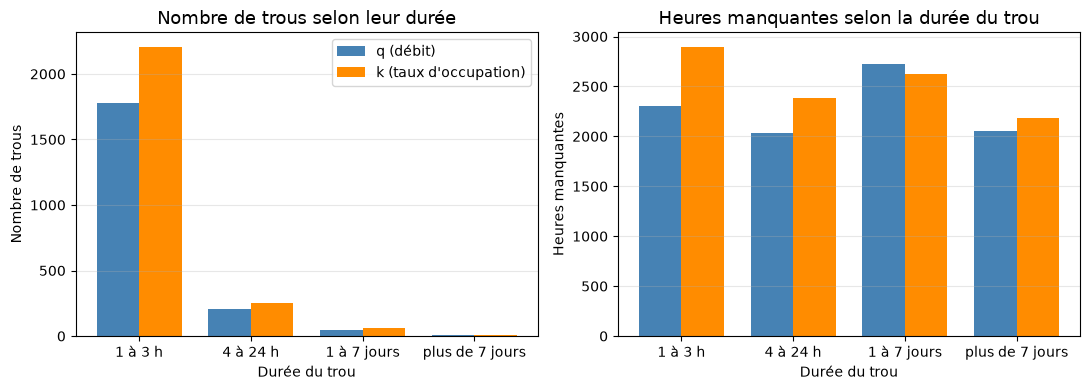

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
largeur = 0.38
positions = range(len(noms_classes))

for ax, mesure, titre, ylabel in [
    (axes[0], "nb_trous", "Nombre de trous selon leur durée", "Nombre de trous"),
    (axes[1], "heures_manquantes", "Heures manquantes selon la durée du trou", "Heures manquantes"),
]:
    ax.bar([p - largeur / 2 for p in positions], bilan_trous["q"][mesure], largeur, label="q (débit)", color="steelblue")
    ax.bar([p + largeur / 2 for p in positions], bilan_trous["k"][mesure], largeur, label="k (taux d'occupation)", color="darkorange")
    ax.set_xticks(list(positions))
    ax.set_xticklabels(noms_classes)
    ax.set_title(titre, fontsize=13)
    ax.set_xlabel("Durée du trou")
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.3)
axes[0].legend()

plt.tight_layout()
plt.show()

**Ce que montrent le tableau et le graphique.** Un « trou » est une suite d'heures consécutives sans valeur, entre la première et la dernière mesure d'un tronçon.

- Les trous sont presque tous très courts : 1 777 des 2 039 trous de `q` (87 %) et 2 207 des 2 520 trous de `k` (88 %) durent de 1 à 3 heures.
- À l'inverse, les longues pannes sont rares mais pèsent lourd : les 53 trous de plus d'un jour représentent 4 773 des 9 113 heures manquantes de `q` (52 %), et les 64 de `k` représentent 4 814 heures sur 10 100 (48 %).

Il y a donc deux situations différentes : des absences ponctuelles, encadrées de près par des mesures réelles, et des pannes de plusieurs jours.

In [35]:
def combler_petits_trous(groupe, colonne, max_trou=3):
    """Interpole linéairement les trous de max_trou heures au plus, laisse les autres vides."""
    s = serie_horaire(groupe, colonne)
    manquant, blocs = blocs_manquants(s)
    petit = manquant & (manquant.groupby(blocs).transform("sum") <= max_trou)
    s = s.where(~petit, s.interpolate(limit_area="inside"))
    return s.reindex(groupe["t_1h"]).to_numpy()

df = df.sort_values(["iu_ac", "t_1h"]).reset_index(drop=True)

for colonne in ["q", "k"]:
    avant = df[colonne].isna().sum()
    for _, groupe in df.groupby("iu_ac"):
        if groupe[colonne].notna().any():
            df.loc[groupe.index, colonne] = combler_petits_trous(groupe, colonne)
    apres = df[colonne].isna().sum()
    print(f"{colonne} : {avant - apres} valeurs imputées, {apres} valeurs manquantes restantes ({apres / len(df) * 100:.1f} % des lignes)")

q : 201 valeurs imputées, 36775 valeurs manquantes restantes (22.1 % des lignes)


k : 819 valeurs imputées, 28418 valeurs manquantes restantes (17.1 % des lignes)


**Choix.**

- Les trous de 1 à 3 heures sont comblés par interpolation linéaire, tronçon par tronçon : la valeur imputée est encadrée par deux mesures réelles distantes de 4 heures au plus.
- Les trous plus longs sont laissés vides. Interpoler sur plusieurs jours tracerait une ligne droite là où le débit varie d'un facteur 5 entre la nuit et la journée, et inventerait du trafic.
- Résultat : 201 valeurs de `q` et 819 valeurs de `k` sont imputées. C'est moins que les 2 306 et 2 897 heures des petits trous, car la plupart de ces heures n'ont pas de ligne à remplir : ce sont les 52 heures absentes de la source pour tous les tronçons, et les lignes `Invalide` ou `Barré` supprimées plus haut.
- Il reste 36 775 valeurs manquantes pour `q` (22,1 % des lignes) et 28 418 pour `k` (17,1 %). Elles viennent des tronçons où une grandeur n'est jamais mesurée (tableau par tronçon plus haut) et des longues pannes : elles sont conservées vides.
- L'état du trafic n'est pas recalculé pour les valeurs de `k` imputées : il reste manquant sur ces lignes.

# Jalon M3 : Transformation et statistiques

### 1. Variables temporelles

Quatre variables sont tirées de `Date_GW` (l'heure de Paris) : l'heure sous forme de nombre, le numéro du jour, son nom, et le type de jour (semaine ou week-end). Elles servent à comparer le trafic selon l'heure et selon le jour.

In [36]:
noms_jours = {0: "lundi", 1: "mardi", 2: "mercredi", 3: "jeudi", 4: "vendredi", 5: "samedi", 6: "dimanche"}

df["Heure_num"] = df["Date_GW"].dt.hour
df["Num_jour"] = df["Date_GW"].dt.dayofweek
df["Jour"] = df["Num_jour"].map(noms_jours)
df["Type_jour"] = df["Num_jour"].map(lambda j: "Week-end" if j >= 5 else "Semaine")

df[["Date_GW", "Heure_num", "Num_jour", "Jour", "Type_jour"]].head()

,Date_GW,Heure_num,Num_jour,Jour,Type_jour
0,2026-03-01 01:00:00+01:00,1,6,dimanche,Week-end
1,2026-03-01 02:00:00+01:00,2,6,dimanche,Week-end
2,2026-03-01 03:00:00+01:00,3,6,dimanche,Week-end
3,2026-03-01 04:00:00+01:00,4,6,dimanche,Week-end
4,2026-03-01 05:00:00+01:00,5,6,dimanche,Week-end


In [37]:
print(df.groupby("Type_jour")["Date"].nunique())
print()
print(df.groupby(["Num_jour", "Jour"])["Date"].nunique())

Type_jour
Semaine     131
Week-end     53
Name: Date, dtype: int64

Num_jour  Jour    
0         lundi       27
1         mardi       26
2         mercredi    26
3         jeudi       26
4         vendredi    26
5         samedi      26
6         dimanche    27
Name: Date, dtype: int64


**Vérification.** La période compte 184 jours : 131 en semaine et 53 de week-end. Chaque jour de la semaine apparaît 26 ou 27 fois : les comparaisons entre jours reposent donc sur des effectifs équivalents.

### 2. Encodage des variables catégorielles

In [38]:
ordre_etats = ["Fluide", "Pré-saturé", "Saturé", "Bloqué"]
df["etat_trafic"] = df["etat_trafic"].cat.set_categories(ordre_etats, ordered=True)
df["etat_trafic_code"] = df["etat_trafic"].cat.codes.where(df["etat_trafic"].notna()).astype("Int8")

df["Week_end"] = (df["Num_jour"] >= 5).astype(int)

df = pd.concat([df, pd.get_dummies(df["libelle"], prefix="axe", dtype=int)], axis=1)

In [39]:
print(df[["etat_trafic", "etat_trafic_code"]].drop_duplicates().sort_values("etat_trafic_code"))
print()
print(df[["libelle", "axe_Av_Daumesnil", "axe_Av_Foch", "axe_Lecourbe"]].drop_duplicates())

      etat_trafic  etat_trafic_code
0          Fluide                 0
15     Pré-saturé                 1
685        Saturé                 2
1477       Bloqué                 3
17503         NaN              <NA>

            libelle  axe_Av_Daumesnil  axe_Av_Foch  axe_Lecourbe
0          Lecourbe                 0            0             1
12765       Av_Foch                 0            1             0
51888  Av_Daumesnil                 1            0             0


**Choix.**

- `etat_trafic` a un ordre naturel (fluide < pré-saturé < saturé < bloqué) : elle est encodée par un rang de 0 à 3 dans `etat_trafic_code`. Les états manquants restent manquants.
- `libelle` n'a aucun ordre : chaque axe devient une colonne 0/1 (`axe_...`). Un code 0, 1, 2 aurait laissé croire qu'un axe « vaut plus » qu'un autre.
- L'état de l'arc (`etat_barre`) a été encodé plus haut, dans la partie nettoyage, par la colonne `arc_ouvert` (0 ou 1). Comme seules les lignes à 1 sont conservées, cette colonne ne varie plus et n'est pas gardée.
- `Type_jour` n'a que deux modalités : une seule colonne `Week_end` (0 ou 1) suffit.

Les colonnes d'origine sont conservées, car elles restent plus lisibles pour les graphiques et les tableaux.

### 3. Valeurs aberrantes

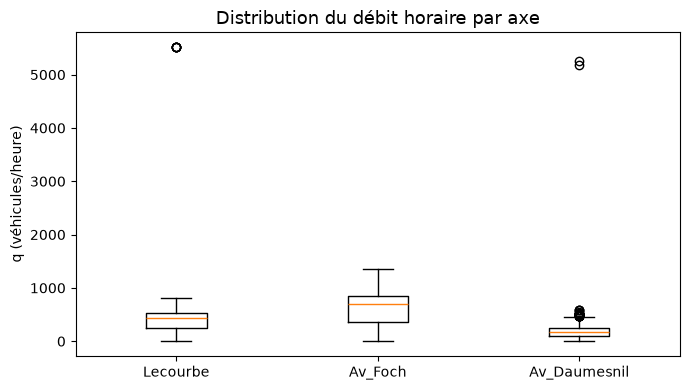

In [40]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([df.loc[df["libelle"] == axe, "q"].dropna() for axe in ROUTES])
ax.set_xticklabels(ROUTES)
ax.set_title("Distribution du débit horaire par axe", fontsize=13)
ax.set_ylabel("q (véhicules/heure)")
plt.tight_layout()
plt.show()

**Ce que montre le graphique.** Sur les trois axes, les débits habituels restent sous 1 400 véhicules/heure, l'avenue Foch étant nettement au-dessus des deux autres. Quelques points isolés dépassent 5 000 véhicules/heure sur la rue Lecourbe et l'avenue Daumesnil, soit plus de six fois le reste de la distribution : ils écrasent l'échelle et ne ressemblent à aucune autre mesure.

In [41]:
def borne_haute(s, facteur):
    q1, q3 = s.quantile([0.25, 0.75])
    return q3 + facteur * (q3 - q1)

borne_globale = borne_haute(df["q"], 1.5)
au_dessus = df[df["q"] > borne_globale]
print(f"Règle globale (1,5 × IQR) : borne à {borne_globale:.0f}, {len(au_dessus)} valeurs au-dessus")
print(au_dessus["libelle"].value_counts())
print()

par_troncon = df.groupby("iu_ac")["q"]
for facteur in (1.5, 3):
    borne = par_troncon.transform(lambda s: borne_haute(s, facteur))
    print(f"Règle par tronçon ({facteur} × IQR) : {(df['q'] > borne).sum()} valeurs au-dessus")

Règle globale (1,5 × IQR) : borne à 868, 6329 valeurs au-dessus
libelle
Av_Foch         6321
Lecourbe           6
Av_Daumesnil       2
Name: count, dtype: int64

Règle par tronçon (1.5 × IQR) : 18 valeurs au-dessus


Règle par tronçon (3 × IQR) : 8 valeurs au-dessus


In [42]:
borne = par_troncon.transform(lambda s: borne_haute(s, 3))
aberrant = df["q"] > borne

df.loc[aberrant, ["iu_ac", "libelle", "Date_GW", "q", "k", "etat_trafic"]].sort_values("Date_GW")

,iu_ac,libelle,Date_GW,q,k,etat_trafic
117297,5581,Lecourbe,2026-03-30 16:00:00+02:00,5517.95,NaN,NaN
121388,5582,Lecourbe,2026-03-30 16:00:00+02:00,5517.95,NaN,NaN
125479,5583,Lecourbe,2026-03-30 16:00:00+02:00,5517.95,NaN,NaN
129570,5584,Lecourbe,2026-03-30 16:00:00+02:00,5517.95,6.64389,Fluide
133661,5585,Lecourbe,2026-03-30 16:00:00+02:00,5517.95,6.64389,Fluide
137752,5586,Lecourbe,2026-03-30 16:00:00+02:00,5517.95,NaN,NaN
71904,4821,Av_Daumesnil,2026-06-17 20:00:00+02:00,5263.95,2.93944,Fluide
73351,4821,Av_Daumesnil,2026-08-17 15:00:00+02:00,5171.95,12.21945,Fluide


In [43]:
print(df[~aberrant].groupby("libelle", observed=True)["q"].max())
print()
print("k : minimum", df["k"].min(), "| maximum", df["k"].max(), "| valeurs hors de 0-100 :", ((df["k"] < 0) | (df["k"] > 100)).sum())

libelle
Av_Daumesnil     595.0
Av_Foch         1357.0
Lecourbe         808.0
Name: q, dtype: float64

k : minimum 0.0 | maximum 97.12778 | valeurs hors de 0-100 : 0


**Constats.**

- Une règle globale ne convient pas : la borne à 868 véhicules/heure signale 6 329 valeurs, dont 6 321 sur l'avenue Foch. Ce n'est pas une anomalie, c'est le trafic normal d'un axe plus chargé que les deux autres.
- La règle est donc appliquée tronçon par tronçon. Avec 1,5 × IQR, 18 valeurs ressortent, dont des débits plausibles (225 à 595 véhicules/heure). Avec 3 × IQR, il en reste 8, toutes au-dessus de 5 000.
- Ces 8 valeurs correspondent à 3 heures seulement : le 30 mars à 16 h sur six tronçons de la rue Lecourbe (5 518), et deux heures sur le tronçon 4821 de l'avenue Daumesnil (5 264 et 5 172). Sans elles, le maximum est de 808 sur Lecourbe et de 595 sur Daumesnil.
- Elles sont incohérentes avec le taux d'occupation mesuré au même moment (3 à 12 %, état « Fluide ») : un débit six fois supérieur au maximum habituel ne peut pas passer sur une voie presque vide.
- Pour `k`, toutes les valeurs sont entre 0 et 97 %, donc dans l'intervalle possible d'un pourcentage. Les valeurs élevées correspondent à de la congestion, pas à une erreur.

In [44]:
df["q"] = df["q"].mask(aberrant)

troncons_concernes = df.loc[aberrant, "iu_ac"].unique()
for _, groupe in df[df["iu_ac"].isin(troncons_concernes)].groupby("iu_ac"):
    df.loc[groupe.index, "q"] = combler_petits_trous(groupe, "q")

print(f"{aberrant.sum()} valeurs aberrantes remplacées, nouveau maximum de q : {df['q'].max():.0f}")
print(df.loc[aberrant, ["iu_ac", "Date_GW", "q"]].sort_values("Date_GW").to_string())

8 valeurs aberrantes remplacées, nouveau maximum de q : 1357
       iu_ac                   Date_GW      q
117297  5581 2026-03-30 16:00:00+02:00  512.0
121388  5582 2026-03-30 16:00:00+02:00  512.0
125479  5583 2026-03-30 16:00:00+02:00  512.0
129570  5584 2026-03-30 16:00:00+02:00  512.0
133661  5585 2026-03-30 16:00:00+02:00  512.0
137752  5586 2026-03-30 16:00:00+02:00  512.0
71904   4821 2026-06-17 20:00:00+02:00  238.5
73351   4821 2026-08-17 15:00:00+02:00  175.5


**Choix.** Les 8 débits aberrants, repérés par la règle 3 × IQR par tronçon, sont remplacés par l'interpolation des deux heures voisines, comme les petits trous de la partie nettoyage : 512 véhicules/heure au lieu de 5 518 sur la rue Lecourbe, 238,5 et 175,5 au lieu de 5 264 et 5 172 sur le tronçon 4821. Les lignes sont conservées, car le taux d'occupation de ces heures reste valide. Aucune valeur de `k` n'est modifiée.

### 4. Statistiques par tronçon

Les statistiques sont calculées pour le débit `q`, puis pour le taux d'occupation `k`, sur les tronçons où la grandeur est mesurée.

In [45]:
stats_q = (
    df.dropna(subset=["q"])
    .groupby(["libelle", "iu_ac"], observed=True)["q"]
    .agg(n="count", moyenne="mean", mediane="median", ecart_type="std", minimum="min", maximum="max")
    .round(1)
)
stats_q

n  moyenne  mediane  ecart_type  minimum  maximum
libelle      iu_ac                                                      
Av_Daumesnil 4795    609    128.0    143.0        58.4     14.0    261.0
             4797   3785    161.3    180.0        73.2     12.0    342.0
             4798   3820    161.2    180.0        73.1     12.0    342.0
             4800   3785    161.3    180.0        73.2     12.0    342.0
             4802    609    128.0    143.0        58.4     14.0    261.0
             4821   1842    158.8    170.0        79.8     14.0    372.0
             4836   4295    153.7    155.0        84.3      4.0    408.0
             4837   4295    153.7    155.0        84.3      4.0    408.0
             4838   4295     86.6     88.0        43.5      3.0    226.0
             4840   4305     86.6     88.0        43.6      3.0    226.0
             4841   4295    153.7    155.0        84.3      4.0    408.0
             4842   4314    184.1    190.0        94.2      0.0    462.0
             4843   3980    222.3    235.0       105.8      0.0    595.0
             4845   4314    211.5    230.0        97.5     16.0    483.0
             5041   4319    211.6    230.0        97.6     16.0    483.0
             5713    609    128.0    143.0        58.4     14.0    261.0
             5797   3973    222.4    235.0       105.8      0.0    595.0
             5798   4314    184.1    190.0        94.2      0.0    462.0
             5800   4314    184.1    190.0        94.2      0.0    462.0
             5801   3973    222.4    235.0       105.8      0.0    595.0
             905    3704    166.6    160.0       101.4      6.0    555.0
             906    3909    161.7    181.0        72.7     12.0    342.0
Av_Foch      4381   4273    731.4    816.0       332.7      0.0   1357.0
             4383   4124    581.6    674.0       301.5      0.0   1121.0
             4384   4275    731.5    816.0       332.7      0.0   1357.0
             4385   4120    581.4    674.0       301.5      0.0   1121.0
             4388   2623    571.7    640.0       263.8      0.0   1034.0
             4389   2609    570.9    640.0       264.0      0.0   1034.0
             4430   2609    570.9    640.0       264.0      0.0   1034.0
             4433   2612    569.7    639.0       265.3      0.0   1034.0
Lecourbe     5581   4091    395.1    431.0       172.4      0.0    808.0
             5582   4091    395.1    431.0       172.4      0.0    808.0
             5583   4091    395.1    431.0       172.4      0.0    808.0
             5584   4091    395.1    431.0       172.4      0.0    808.0
             5585   4091    395.1    431.0       172.4      0.0    808.0
             5586   4091    395.1    431.0       172.4      0.0    808.0

In [46]:
stats_k = (
    df.dropna(subset=["k"])
    .groupby(["libelle", "iu_ac"], observed=True)["k"]
    .agg(n="count", moyenne="mean", mediane="median", ecart_type="std", minimum="min", maximum="max")
    .round(1)
)
stats_k[stats_k["n"] >= 100]  # les tronçons avec une poignée de mesures ne sont pas interprétables

n  moyenne  mediane  ecart_type  minimum  maximum
libelle      iu_ac                                                      
Av_Daumesnil 4795   4022      3.6      3.5         2.2      0.1     13.5
             4797   3987      1.2      1.0         1.4      0.0     14.4
             4798    633      2.6      2.6         1.7      0.3     20.0
             4800   3987      1.2      1.0         1.4      0.0     14.4
             4802   4022      3.6      3.5         2.2      0.1     13.5
             4821   1843      4.2      2.4         5.3      0.2     57.1
             4836   4295      4.9      1.9         8.2      0.0     61.8
             4837   4201      1.7      1.5         1.6      0.0     36.7
             4838   4295      2.4      1.2         5.7      0.0     68.7
             4840   4049      2.3      2.1         1.8      0.2     16.8
             4841   4201      1.7      1.5         1.6      0.0     36.7
             4842   4314      3.1      3.1         2.1      0.0     30.1
             4843   4314      3.6      3.5         2.6      0.2     54.5
             4845   4314      3.7      3.9         1.8      0.3     13.3
             4846   4175      3.7      3.5         2.6      0.2     57.0
             5041   4033      3.2      3.0         2.5      0.0     47.0
             5713    609      2.3      2.2         2.0      0.2     30.0
             5797   3846     19.9      6.5        24.6      0.3     97.1
             5798   3853      7.4      5.6         6.5      0.3     50.4
             5800   3853      7.4      5.6         6.5      0.3     50.4
             5801   3846     19.9      6.5        24.6      0.3     97.1
             906    3882     20.6     13.7        20.1      0.0     78.1
Av_Foch      4381   4273      2.9      3.1         1.6      0.0     20.0
             4383   4274      5.9      4.6         6.0      0.0     63.1
             4384   4123     14.6     10.2        13.6      0.0     82.8
             4385   4103      9.1      9.1         5.9      0.0     46.4
             4388   4215      6.3      4.2         7.4      0.0     58.4
             4430   2598      3.9      4.3         1.8      0.0     12.6
             4432   4186      9.4      7.0         9.8      0.0     67.3
             4433   4256     17.2     17.7         7.8      0.0     58.5
             4435   4256      9.4      9.8         4.9      0.0     42.4
Lecourbe     1117   4255      8.7      6.4         8.3      0.2     54.3
             1119   4255      8.7      6.4         8.3      0.2     54.3
             1120   4255      8.7      6.4         8.3      0.2     54.3
             5584   4089      1.9      1.6         1.5      0.2     25.6
             5585   4089      1.9      1.6         1.5      0.2     25.6

In [47]:
profils = (
    stats_q.reset_index()
    .groupby(["libelle", "minimum", "maximum"], observed=True)
    .agg(nb_troncons=("iu_ac", "size"), troncons=("iu_ac", ", ".join),
         moyenne_min=("moyenne", "min"), moyenne_max=("moyenne", "max"))
    .reset_index()
)
print(f"{len(stats_q)} tronçons ont un débit, pour {len(profils)} profils distincts (même minimum et même maximum)")
profils[profils["nb_troncons"] > 1][["libelle", "minimum", "maximum", "moyenne_min", "moyenne_max", "nb_troncons", "troncons"]]

36 tronçons ont un débit, pour 13 profils distincts (même minimum et même maximum)


,libelle,minimum,maximum,moyenne_min,moyenne_max,nb_troncons,troncons
0,Av_Daumesnil,0.0,462.0,184.1,184.1,3,"4842, 5798, 5800"
1,Av_Daumesnil,0.0,595.0,222.3,222.4,3,"4843, 5797, 5801"
2,Av_Daumesnil,3.0,226.0,86.6,86.6,2,"4838, 4840"
3,Av_Daumesnil,4.0,408.0,153.7,153.7,3,"4836, 4837, 4841"
5,Av_Daumesnil,12.0,342.0,161.2,161.7,4,"4797, 4798, 4800, 906"
6,Av_Daumesnil,14.0,261.0,128.0,128.0,3,"4795, 4802, 5713"
8,Av_Daumesnil,16.0,483.0,211.5,211.6,2,"4845, 5041"
9,Av_Foch,0.0,1034.0,569.7,571.7,4,"4388, 4389, 4430, 4433"
10,Av_Foch,0.0,1121.0,581.4,581.6,2,"4383, 4385"
11,Av_Foch,0.0,1357.0,731.4,731.5,2,"4381, 4384"


**Ce que montrent les tableaux.**

- Les tronçons de l'avenue Foch ont les débits les plus élevés : entre 570 et 731 véhicules/heure en moyenne, avec un maximum de 1 357. La rue Lecourbe est à 395 en moyenne, et les tronçons de l'avenue Daumesnil entre 87 et 222.
- L'écart-type est important partout (entre 44 % et 61 % de la moyenne selon le tronçon) : le débit varie beaucoup au cours de la journée.
- Piège des données : 36 tronçons ont un débit, mais seulement 13 profils distincts. Plusieurs tronçons voisins ont exactement le même minimum et le même maximum, et des moyennes identiques ou presque (les petits écarts viennent des valeurs imputées) ; c'est le cas des six tronçons de la rue Lecourbe. Le débit semble mesuré en un point et recopié sur les tronçons voisins. Les moyennes par axe comptent donc plusieurs fois le même point de mesure.
- Le taux d'occupation, lui, diffère d'un tronçon à l'autre. Les plus occupés en moyenne sont 906, 5797 et 5801 sur l'avenue Daumesnil (environ 20 %) et 4433 sur l'avenue Foch (17 %). Les tronçons avec moins de 100 mesures de `k` ne sont pas affichés.

In [48]:
profil_horaire = (
    df.groupby(["libelle", "iu_ac", "Heure_num"], observed=True)["q"]
    .mean()
    .unstack("Heure_num")
    .dropna(how="all")
)

pointe = pd.DataFrame({
    "heure_la_plus_chargee": profil_horaire.idxmax(axis=1),
    "debit_moyen_a_cette_heure": profil_horaire.max(axis=1).round(0),
    "heure_la_plus_creuse": profil_horaire.idxmin(axis=1),
    "debit_moyen_heure_creuse": profil_horaire.min(axis=1).round(0),
})
pointe

heure_la_plus_chargee  debit_moyen_a_cette_heure  \
libelle      iu_ac                                                     
Av_Daumesnil 4795                      12                      181.0   
             4797                      10                      227.0   
             4798                      10                      227.0   
             4800                      10                      227.0   
             4802                      12                      181.0   
             4821                      11                      226.0   
             4836                      17                      243.0   
             4837                      17                      243.0   
             4838                      12                      133.0   
             4840                      12                      133.0   
             4841                      17                      243.0   
             4842                      17                      293.0   
             4843                      16                      310.0   
             4845                      12                      322.0   
             5041                      12                      322.0   
             5713                      12                      181.0   
             5797                      16                      310.0   
             5798                      17                      293.0   
             5800                      17                      293.0   
             5801                      16                      310.0   
             905                       18                      282.0   
             906                       11                      226.0   
Av_Foch      4381                      19                     1013.0   
             4383                      10                      822.0   
             4384                      19                     1013.0   
             4385                      10                      822.0   
             4388                      17                      809.0   
             4389                      17                      809.0   
             4430                      17                      809.0   
             4433                      17                      801.0   
Lecourbe     5581                      20                      558.0   
             5582                      20                      558.0   
             5583                      20                      558.0   
             5584                      20                      558.0   
             5585                      20                      558.0   
             5586                      20                      558.0   

                    heure_la_plus_creuse  debit_moyen_heure_creuse  
libelle      iu_ac                                                  
Av_Daumesnil 4795                      4                      30.0  
             4797                      4                      40.0  
             4798                      4                      40.0  
             4800                      4                      40.0  
             4802                      4                      30.0  
             4821                      4                      36.0  
             4836                      5                      27.0  
             4837                      5                      27.0  
             4838                      5                      24.0  
             4840                      5                      24.0  
             4841                      5                      27.0  
             4842                      5                      36.0  
             4843                      5                     102.0  
             4845                      4                      49.0  
             5041                      4                      49.0  
             5713                      4                      30.0  
             5797                      5 

In [49]:
debit_axe_heure = df.groupby(["libelle", "Heure_num"], observed=True)["q"].mean().round(0)
for axe in ROUTES:
    print(axe, ": 3 heures les plus chargées")
    print(debit_axe_heure[axe].nlargest(3).to_string())
    print()

Lecourbe : 3 heures les plus chargées
Heure_num
20    558.0
19    557.0
18    534.0

Av_Foch : 3 heures les plus chargées
Heure_num
17    853.0
18    852.0
19    849.0

Av_Daumesnil : 3 heures les plus chargées
Heure_num
12    240.0
17    240.0
13    236.0



**Heures les plus chargées.**

- Avenue Foch : le trafic culmine en fin de journée, entre 17 h et 19 h (environ 850 véhicules/heure en moyenne sur l'axe). Deux tronçons (4383 et 4385) ont au contraire leur maximum à 10 h.
- Rue Lecourbe : le pic est tardif, entre 18 h et 20 h (environ 558 véhicules/heure à 20 h).
- Avenue Daumesnil : le profil est plus étalé, avec deux maximums proches à 12 h et à 17 h (240 véhicules/heure). Selon le tronçon, l'heure la plus chargée va de 10 h à 18 h.
- Sur tous les tronçons, l'heure la plus creuse se situe entre 4 h et 6 h du matin.

In [50]:
print(df.shape)
df.dtypes

(166224, 21)


iu_ac                                     string
libelle                                 category
t_1h                         datetime64[us, UTC]
q                                        float64
k                                        float64
etat_trafic                             category
libelle_nd_amont                             str
libelle_nd_aval                              str
Date_GW             datetime64[us, Europe/Paris]
Date                                      object
Heure                                        str
Mois                                         str
Heure_num                                  int32
Num_jour                                   int32
Jour                                         str
Type_jour                                    str
etat_trafic_code                            Int8
Week_end                                   int64
axe_Av_Daumesnil                           int64
axe_Av_Foch                                int64
axe_Lecourbe        

# Jalon 4 : Analyse et présentation

Cette partie répond à la question de départ : comment le trafic évolue-t-il sur les trois axes, au fil des mois, selon l'heure et selon le jour ? Les graphiques utilisent les données nettoyées et les variables créées dans les parties précédentes. Chaque axe garde la même couleur d'un graphique à l'autre.

In [51]:
import seaborn as sns

NOMS_AXES = {"Lecourbe": "Rue Lecourbe", "Av_Foch": "Avenue Foch", "Av_Daumesnil": "Avenue Daumesnil"}
COULEURS_AXES = {"Lecourbe": "#0072B2", "Av_Foch": "#D55E00", "Av_Daumesnil": "#009E73"}
COULEURS_ETATS = {"Fluide": "#4575b4", "Pré-saturé": "#e6ab02", "Saturé": "#f46d43", "Bloqué": "#a50026"}
ORDRE_JOURS = list(noms_jours.values())

DOSSIER_IMAGES = Path("images")
DOSSIER_IMAGES.mkdir(exist_ok=True)

### 1. Évolution de mars à août

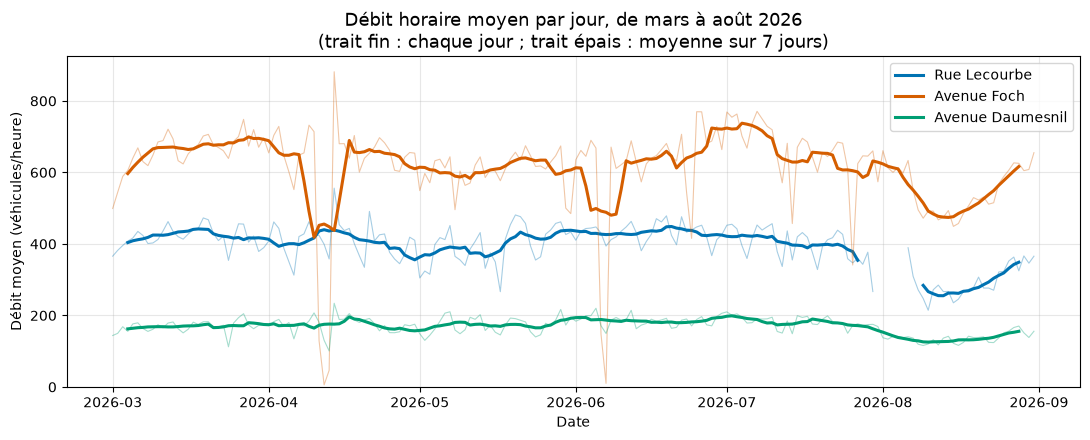

In [52]:
debit_date = df.groupby(["Date", "libelle"], observed=True)["q"].mean().unstack("libelle")[ROUTES]
debit_date.index = pd.to_datetime(debit_date.index)
debit_lisse = debit_date.rolling(7, center=True).mean()

fig, ax = plt.subplots(figsize=(11, 4.5))
for axe in ROUTES:
    ax.plot(debit_date.index, debit_date[axe], color=COULEURS_AXES[axe], linewidth=0.8, alpha=0.35)
    ax.plot(debit_lisse.index, debit_lisse[axe], color=COULEURS_AXES[axe], linewidth=2.2, label=NOMS_AXES[axe])
ax.set_title("Débit horaire moyen par jour, de mars à août 2026\n(trait fin : chaque jour ; trait épais : moyenne sur 7 jours)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Débit moyen (véhicules/heure)")
ax.set_ylim(0)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
fig.savefig(DOSSIER_IMAGES / "evolution_mars_aout.png", dpi=150)
plt.show()

In [53]:
ordre_mois = ["mars", "avril", "mai", "juin", "juillet", "août"]

debit_mois = df.groupby(["Mois", "libelle"], observed=True)["q"].mean().unstack("libelle").loc[ordre_mois, ROUTES]
print("Débit moyen par mois (véhicules/heure)")
print(debit_mois.round(0))
print()
print("Écart août / juin (%)")
print(((debit_mois.loc["août"] / debit_mois.loc["juin"] - 1) * 100).round(1))
print()

troncons_mois = (
    df.dropna(subset=["q"]).groupby(["Mois", "libelle"], observed=True)["iu_ac"].nunique()
    .unstack("libelle").loc[ordre_mois, ROUTES]
)
print("Nombre de tronçons avec un débit mesuré, par mois")
print(troncons_mois)
print()
print("Jours extrêmes (moyenne sur 7 jours)")
for axe in ROUTES:
    print(f"{axe} : maximum {debit_lisse[axe].max():.0f} autour du {debit_lisse[axe].idxmax():%d/%m}, minimum {debit_lisse[axe].min():.0f} autour du {debit_lisse[axe].idxmin():%d/%m}")

Débit moyen par mois (véhicules/heure)
libelle  Lecourbe  Av_Foch  Av_Daumesnil
Mois                                    
mars        421.0    660.0         171.0
avril       408.0    629.0         177.0
mai         396.0    605.0         173.0
juin        431.0    625.0         185.0
juillet     399.0    662.0         182.0
août        295.0    543.0         137.0

Écart août / juin (%)
libelle
Lecourbe       -31.5
Av_Foch        -13.0
Av_Daumesnil   -25.9
dtype: float64



Nombre de tronçons avec un débit mesuré, par mois
libelle  Lecourbe  Av_Foch  Av_Daumesnil
Mois                                    
mars            6        8            18
avril           6        8            18
mai             6        8            18
juin            6        8            19
juillet         6        4            19
août            6        4            22

Jours extrêmes (moyenne sur 7 jours)
Lecourbe : maximum 449 autour du 20/06, minimum 255 autour du 13/08
Av_Foch : maximum 738 autour du 04/07, minimum 419 autour du 10/04
Av_Daumesnil : maximum 199 autour du 02/07, minimum 125 autour du 10/08


**Ce que montre le graphique.**

- De mars à juillet, le trafic est stable sur les trois axes : la moyenne mensuelle reste entre 396 et 431 véhicules/heure sur la rue Lecourbe et entre 171 et 185 sur l'avenue Daumesnil.
- En août, le trafic chute nettement : -31,5 % par rapport à juin sur la rue Lecourbe (295 contre 431) et -25,9 % sur l'avenue Daumesnil (137 contre 185). Le creux est atteint vers le 10-13 août, puis le trafic remonte en fin de mois. C'est l'effet des vacances d'été.
- L'avenue Foch baisse aussi en août (-13,0 %), mais sa courbe est à lire avec prudence : à partir de juillet, seuls 4 tronçons sur 8 ont encore un débit mesuré, et ce sont les plus chargés. La moyenne de l'axe ne porte donc plus sur les mêmes tronçons. Les creux brusques du 11 au 13 avril et des 6 et 7 juin sont d'une autre nature : le débit mesuré y est presque nul (6 véhicules/heure en moyenne le 12 avril, 10 le 7 juin), ce qui ressemble à une fermeture ponctuelle de l'avenue plutôt qu'à une baisse du trafic.
- La courbe de la rue Lecourbe s'interrompt du 31 juillet au 5 août : aucun débit n'y est mesuré sur ces six jours.
- Les petites oscillations régulières du trait fin sont le rythme de la semaine, analysé plus bas.

### 2. Trafic selon l'heure

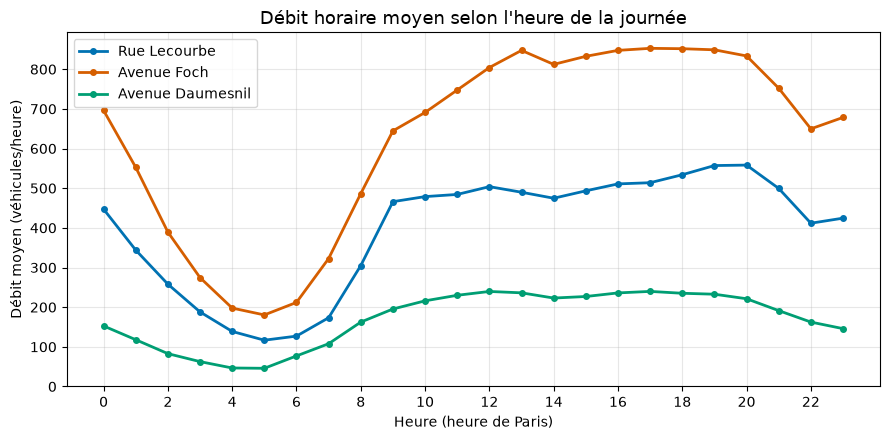

In [54]:
debit_heure = df.groupby(["Heure_num", "libelle"], observed=True)["q"].mean().unstack("libelle")[ROUTES]

fig, ax = plt.subplots(figsize=(9, 4.5))
for axe in ROUTES:
    ax.plot(debit_heure.index, debit_heure[axe], color=COULEURS_AXES[axe], linewidth=2,
            marker="o", markersize=4, label=NOMS_AXES[axe])
ax.set_title("Débit horaire moyen selon l'heure de la journée", fontsize=13)
ax.set_xlabel("Heure (heure de Paris)")
ax.set_ylabel("Débit moyen (véhicules/heure)")
ax.set_xticks(range(0, 24, 2))
ax.set_ylim(0)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
fig.savefig(DOSSIER_IMAGES / "debit_par_heure.png", dpi=150)
plt.show()

In [55]:
resume_heure = pd.DataFrame({
    "heure_max": debit_heure.idxmax(),
    "debit_max": debit_heure.max().round(0),
    "heure_min": debit_heure.idxmin(),
    "debit_min": debit_heure.min().round(0),
    "debit_8h": debit_heure.loc[8].round(0),
    "debit_18h": debit_heure.loc[18].round(0),
})
resume_heure["rapport_max_min"] = (resume_heure["debit_max"] / resume_heure["debit_min"]).round(1)
resume_heure

,heure_max,debit_max,heure_min,debit_min,debit_8h,debit_18h,rapport_max_min
libelle,,,,,,,
Lecourbe,20,558.0,5,117.0,305.0,534.0,4.8
Av_Foch,17,853.0,5,180.0,486.0,852.0,4.7
Av_Daumesnil,17,240.0,5,46.0,162.0,235.0,5.2


**Ce que montre le graphique.**

- Les trois axes suivent le même rythme : un creux à 5 h du matin, une montée rapide entre 6 h et 9 h, puis un niveau élevé jusqu'à 20 h. Le débit est environ 5 fois plus fort à l'heure la plus chargée qu'à l'heure la plus creuse (4,7 à 5,2 selon l'axe).
- L'avenue Foch est la plus chargée à toute heure : 853 véhicules/heure à 17 h, contre 558 sur la rue Lecourbe (à 20 h) et 240 sur l'avenue Daumesnil (à 17 h). À son minimum (180 à 5 h), elle est encore au niveau du débit moyen de l'avenue Daumesnil (170).
- Il n'y a pas de pic du matin marqué : à 8 h, le débit est encore loin du niveau du soir (486 contre 852 à 18 h sur l'avenue Foch). Le trafic forme plutôt un plateau de 9 h à 20 h, et le maximum arrive en fin de journée.
- Le trafic reste soutenu tard : à minuit, l'avenue Foch compte encore près de 700 véhicules/heure.

### 3. Semaine et week-end

Les trois graphiques ont chacun leur échelle verticale, car les niveaux de débit sont très différents d'un axe à l'autre : ils se comparent par la forme des courbes, pas par leur hauteur.

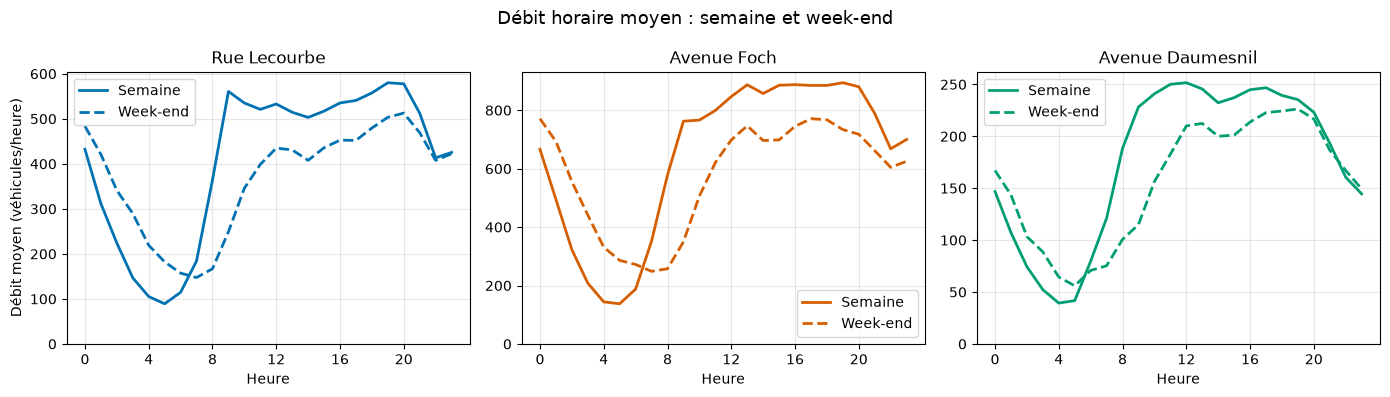

In [56]:
debit_type = df.groupby(["libelle", "Type_jour", "Heure_num"], observed=True)["q"].mean()

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
for ax, axe in zip(axes, ROUTES):
    ax.plot(debit_type[axe]["Semaine"], color=COULEURS_AXES[axe], linewidth=2, label="Semaine")
    ax.plot(debit_type[axe]["Week-end"], color=COULEURS_AXES[axe], linewidth=2, linestyle="--", label="Week-end")
    ax.set_title(NOMS_AXES[axe])
    ax.set_xlabel("Heure")
    ax.set_xticks(range(0, 24, 4))
    ax.set_ylim(0)
    ax.grid(alpha=0.3)
    ax.legend()
axes[0].set_ylabel("Débit moyen (véhicules/heure)")
fig.suptitle("Débit horaire moyen : semaine et week-end", fontsize=13)
plt.tight_layout()
fig.savefig(DOSSIER_IMAGES / "semaine_weekend.png", dpi=150)
plt.show()

In [57]:
comparaison = df.groupby(["libelle", "Type_jour"], observed=True)["q"].mean().unstack().loc[ROUTES]
comparaison["ecart_%"] = (comparaison["Week-end"] / comparaison["Semaine"] - 1) * 100
print(comparaison.round(1))
print()

profil_type = debit_type.unstack("Heure_num")
print(pd.DataFrame({
    "heure_max": profil_type.idxmax(axis=1),
    "debit_max": profil_type.max(axis=1).round(0),
    "debit_8h": profil_type[8].round(0),
    "debit_2h": profil_type[2].round(0),
}))

Type_jour     Semaine  Week-end  ecart_%
libelle                                 
Lecourbe        406.9     367.1     -9.8
Av_Foch         644.6     574.0    -11.0
Av_Daumesnil    175.6     156.0    -11.2

                        heure_max  debit_max  debit_8h  debit_2h
libelle      Type_jour                                          
Av_Daumesnil Semaine           12      252.0     188.0      74.0
             Week-end          19      226.0     101.0     103.0
Av_Foch      Semaine           19      894.0     579.0     323.0
             Week-end          17      771.0     257.0     556.0
Lecourbe     Semaine           19      580.0     364.0     224.0
             Week-end          20      513.0     167.0     341.0


**Ce que montre le graphique.**

- Le week-end, le débit moyen baisse d'environ 10 % sur les trois axes : -9,8 % sur la rue Lecourbe, -11,0 % sur l'avenue Foch, -11,2 % sur l'avenue Daumesnil.
- La différence vient surtout du matin. À 8 h, le débit du week-end est environ deux fois plus faible qu'en semaine : 257 contre 579 sur l'avenue Foch, 167 contre 364 sur la rue Lecourbe. Le trafic démarre environ deux heures plus tard.
- La nuit, c'est l'inverse : à 2 h du matin, le trafic est plus fort le week-end (556 contre 323 sur l'avenue Foch, 341 contre 224 sur la rue Lecourbe). Ce sont les sorties du vendredi et du samedi soir.
- En fin de soirée (après 21 h), les deux courbes se rejoignent sur la rue Lecourbe et l'avenue Daumesnil ; sur l'avenue Foch, la semaine reste un peu au-dessus.

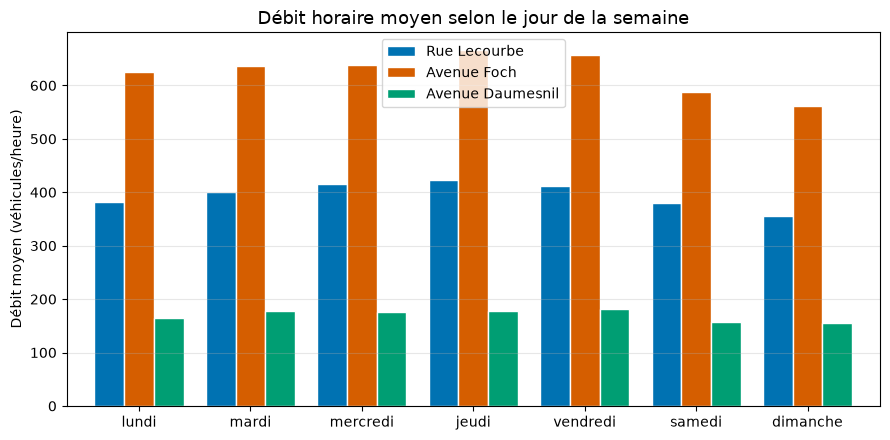

libelle   Lecourbe  Av_Foch  Av_Daumesnil
lundi        381.0    625.0         165.0
mardi        401.0    636.0         177.0
mercredi     416.0    638.0         176.0
jeudi        422.0    666.0         178.0
vendredi     412.0    658.0         182.0
samedi       380.0    587.0         158.0
dimanche     355.0    561.0         154.0


In [58]:
debit_jour = df.groupby(["Num_jour", "libelle"], observed=True)["q"].mean().unstack("libelle")[ROUTES]
debit_jour.index = ORDRE_JOURS

ax = debit_jour.rename(columns=NOMS_AXES).plot.bar(
    figsize=(9, 4.5), width=0.8, color=[COULEURS_AXES[axe] for axe in ROUTES], edgecolor="white")
ax.set_title("Débit horaire moyen selon le jour de la semaine", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("Débit moyen (véhicules/heure)")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(debit_jour.round(0))

**Ce que montre le graphique.** Le trafic augmente légèrement du lundi au jeudi ou vendredi, puis baisse le week-end. Le jour le plus chargé est le jeudi sur la rue Lecourbe (422 véhicules/heure) et l'avenue Foch (666), le vendredi sur l'avenue Daumesnil (182). Le dimanche est le jour le plus calme sur les trois axes (355, 561 et 154). L'écart entre le jour le plus chargé et le dimanche est d'environ 19 % sur chaque axe, bien plus faible que l'écart entre les heures d'une même journée.

### 4. Heatmap jour × heure

Chaque case donne le débit moyen pour un jour et une heure. Chaque axe a sa propre échelle de couleur.

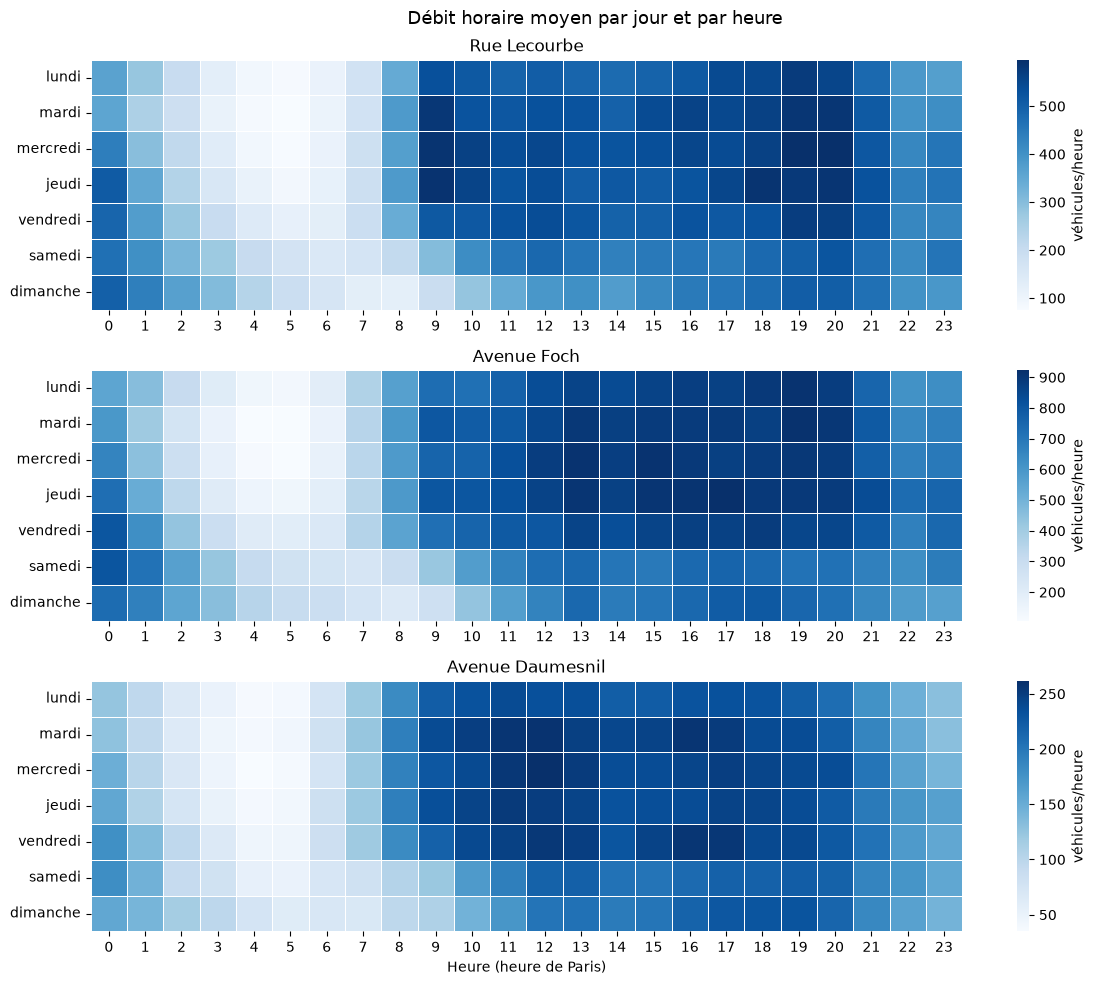

In [59]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
grilles = {}
for ax, axe in zip(axes, ROUTES):
    grille = df[df["libelle"] == axe].pivot_table(index="Num_jour", columns="Heure_num", values="q", aggfunc="mean")
    grille.index = ORDRE_JOURS
    grilles[axe] = grille
    sns.heatmap(grille, cmap="Blues", ax=ax, linewidths=0.5, linecolor="white",
                cbar_kws={"label": "véhicules/heure"})
    ax.set_title(NOMS_AXES[axe])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="y", rotation=0)
axes[-1].set_xlabel("Heure (heure de Paris)")
fig.suptitle("Débit horaire moyen par jour et par heure", fontsize=13)
plt.tight_layout()
fig.savefig(DOSSIER_IMAGES / "heatmap_jour_heure.png", dpi=150)
plt.show()

In [60]:
for axe in ROUTES:
    cases = grilles[axe].stack()
    jour_max, heure_max = cases.idxmax()
    jour_min, heure_min = cases.idxmin()
    print(f"{NOMS_AXES[axe]} : maximum {cases.max():.0f} le {jour_max} à {heure_max} h, "
          f"minimum {cases.min():.0f} le {jour_min} à {heure_min} h")
    print("   3 cases les plus chargées :", [(j, h, round(v)) for (j, h), v in cases.nlargest(3).items()])

Rue Lecourbe : maximum 597 le mercredi à 20 h, minimum 75 le mardi à 5 h
   3 cases les plus chargées : [('mercredi', 20, 597), ('mercredi', 19, 596), ('jeudi', 9, 589)]
Avenue Foch : maximum 923 le jeudi à 17 h, minimum 106 le mardi à 4 h
   3 cases les plus chargées : [('jeudi', 17, 923), ('mardi', 19, 916), ('mercredi', 13, 913)]
Avenue Daumesnil : maximum 262 le mercredi à 12 h, minimum 35 le mercredi à 4 h
   3 cases les plus chargées : [('mercredi', 12, 262), ('mardi', 12, 259), ('mardi', 11, 257)]


**Ce que montre le graphique.**

- Du lundi au vendredi, une bande sombre va de 9 h à 20 h : c'est le plateau de la journée, presque identique d'un jour ouvré à l'autre.
- Le samedi et le dimanche, cette bande commence plus tard (vers 11 h) et elle est plus claire : on retrouve le démarrage tardif du week-end.
- En bas à gauche, les cases de 0 h à 2 h sont plus sombres le samedi et le dimanche qu'en semaine : ce sont les nuits de vendredi à samedi et de samedi à dimanche.
- Les cases les plus chargées diffèrent selon l'axe : le mercredi à 20 h sur la rue Lecourbe (597 véhicules/heure), le jeudi à 17 h sur l'avenue Foch (923), le mercredi à 12 h sur l'avenue Daumesnil (262). L'avenue Daumesnil est la seule dont le maximum tombe à midi et non en soirée.
- Les cases les plus creuses sont toujours en semaine, entre 4 h et 5 h du matin (75, 106 et 35 véhicules/heure).

### 5. Diagramme fondamental : débit et taux d'occupation

Chaque point est une mesure horaire d'un tronçon, placée selon son taux d'occupation `k` et son débit `q`. Seules les mesures où les deux grandeurs et l'état du trafic sont connus sont utilisées.

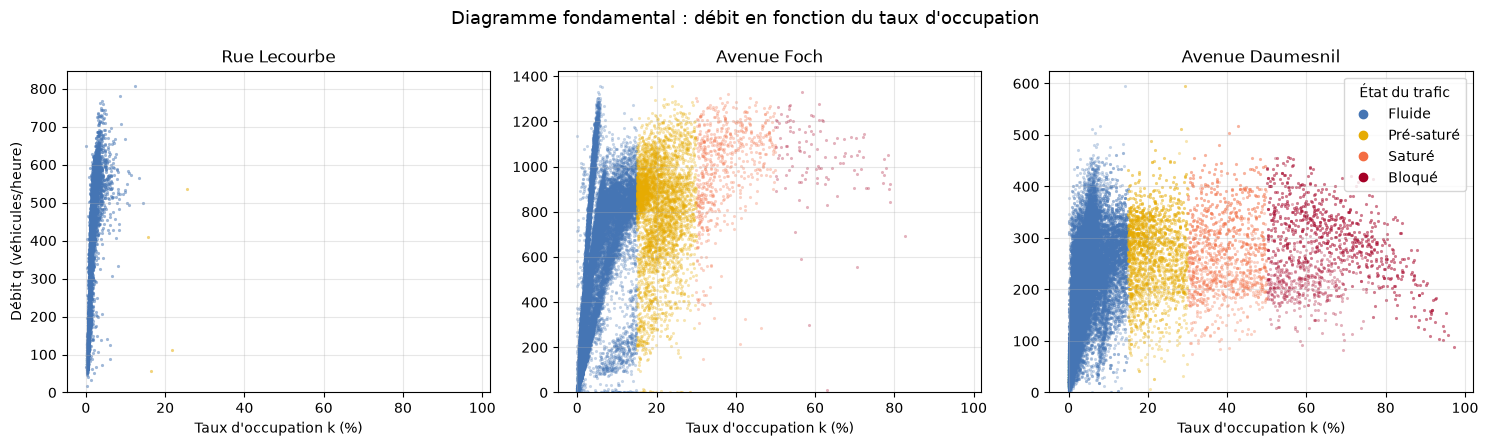

In [61]:
complet = df.dropna(subset=["q", "k", "etat_trafic"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)
for ax, axe in zip(axes, ROUTES):
    points = complet[complet["libelle"] == axe]
    for etat in ordre_etats:
        sous = points[points["etat_trafic"] == etat]
        ax.scatter(sous["k"], sous["q"], s=5, alpha=0.3, color=COULEURS_ETATS[etat], linewidths=0, rasterized=True)
    ax.set_title(NOMS_AXES[axe])
    ax.set_xlabel("Taux d'occupation k (%)")
    ax.set_ylim(0)
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Débit q (véhicules/heure)")
poignees = [plt.Line2D([], [], marker="o", linestyle="", color=COULEURS_ETATS[etat], label=etat) for etat in ordre_etats]
axes[-1].legend(handles=poignees, title="État du trafic", loc="upper right")
fig.suptitle("Diagramme fondamental : débit en fonction du taux d'occupation", fontsize=13)
plt.tight_layout()
fig.savefig(DOSSIER_IMAGES / "diagramme_fondamental.png", dpi=150)
plt.show()

In [62]:
print(len(complet), "mesures avec q, k et état du trafic")
print(complet.groupby("libelle", observed=True).size())
print()
print(complet.groupby("etat_trafic", observed=True)["k"].agg(["count", "min", "median", "max"]).round(1))
print()

tranches = pd.cut(complet["k"], [0, 5, 10, 15, 20, 30, 50, 100], include_lowest=True)
print(complet.groupby([tranches, "libelle"], observed=True)["q"].mean().unstack("libelle")[ROUTES].round(0))

100212 mesures avec q, k et état du trafic
libelle
Av_Daumesnil    67637
Av_Foch         24395
Lecourbe         8180
dtype: int64

             count   min  median   max
etat_trafic                           
Fluide       90048   0.0     2.3  15.0
Pré-saturé    6301  15.0    19.9  30.0
Saturé        2017  30.0    37.6  50.0
Bloqué        1846  50.0    62.9  97.1

libelle        Lecourbe  Av_Foch  Av_Daumesnil
k                                             
(-0.001, 5.0]     391.0    472.0         141.0
(5.0, 10.0]       546.0    730.0         260.0
(10.0, 15.0]      572.0    770.0         263.0
(15.0, 20.0]      232.0    789.0         268.0
(20.0, 30.0]      324.0    831.0         275.0
(30.0, 50.0]        NaN    996.0         280.0
(50.0, 100.0]       NaN   1033.0         282.0


**Ce que montre le graphique.**

- Le nuage repose sur 100 212 mesures, très inégalement réparties : 67 637 sur l'avenue Daumesnil, 24 395 sur l'avenue Foch et seulement 8 180 sur la rue Lecourbe, où peu de tronçons mesurent à la fois `q` et `k`.
- L'état du trafic est entièrement déterminé par le taux d'occupation : « Fluide » jusqu'à 15 %, « Pré-saturé » de 15 à 30 %, « Saturé » de 30 à 50 %, « Bloqué » au-delà. Les couleurs forment donc des bandes verticales.
- À faible occupation, le débit augmente avec `k` : plus il y a de véhicules sur la voie, plus il en passe. Sur l'avenue Daumesnil, le débit moyen passe de 141 véhicules/heure (occupation de 0 à 5 %) à 260 (5 à 10 %).
- Au-delà, le débit plafonne : sur l'avenue Daumesnil, il reste entre 263 et 282 de 10 % à 100 % d'occupation. Davantage de véhicules sur la voie ne font plus passer davantage de véhicules : c'est la congestion. Le nuage redescend même nettement au-delà de 80 % d'occupation.
- Sur l'avenue Foch, le débit continue de monter plus longtemps (jusqu'à environ 1 000 véhicules/heure entre 30 et 50 % d'occupation) avant de se stabiliser : l'axe a une capacité bien plus grande.
- La rue Lecourbe reste presque toujours fluide sur les tronçons mesurés : la quasi-totalité des points est sous 15 % d'occupation. On n'y observe donc pas la partie congestionnée du diagramme.

## Conclusion

- **L'axe le plus chargé est l'avenue Foch**, à toute heure et tous les jours : environ 620 véhicules/heure en moyenne, contre 396 sur la rue Lecourbe et 170 sur l'avenue Daumesnil.
- **Le trafic suit surtout l'heure de la journée** : il est environ 5 fois plus fort à l'heure la plus chargée qu'au creux de 5 h du matin. Il n'y a pas de pic du matin marqué, mais un plateau de 9 h à 20 h, avec un maximum en fin de journée.
- **Le trafic est stable de mars à juillet, puis chute en août** : -31,5 % sur la rue Lecourbe et -25,9 % sur l'avenue Daumesnil par rapport à juin.
- **Le week-end réduit le trafic d'environ 10 %** et le décale : il démarre plus tard le matin et il est plus fort la nuit.
- **Le jour de la semaine compte peu** : environ 19 % d'écart entre le jour le plus chargé et le dimanche.
- **La congestion se voit sur l'avenue Daumesnil et l'avenue Foch**, où le débit plafonne quand le taux d'occupation augmente. La rue Lecourbe reste presque toujours fluide sur les tronçons mesurés.

**Limites.** Une part importante des mesures est manquante et concentrée sur certains tronçons. Plusieurs tronçons voisins portent exactement le même débit, ce qui pèse sur les moyennes par axe. Sur l'avenue Foch, la moitié des tronçons n'a plus de débit mesuré à partir de juillet, ce qui fragilise la comparaison entre mois. Enfin, la période couvre six mois, dont les vacances d'été : les résultats ne décrivent pas une année entière.